In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# EDA – Chargeback Fraud Challenge
Chaque ligne correspond à un compte client au moment où la plateforme doit décider d’autoriser, bloquer ou revoir une activité. L’objectif est de prédire la variable binaire target_is_fraud (1 = chargeback / fraude, 0 = comportement normal) pour construire un modèle de détection de fraude exploitable.

## Chargement des données & aperçu global

In [59]:
df = pd.read_csv('../data/kaggle_b2_fraud_train_v4.csv')
df

,customer_id,account_id,age,tenure_months,annual_income_eur,credit_score,num_transactions_30d,avg_amount_30d_eur,max_amount_30d_eur,days_since_last_login,...,internal_signal_2,internal_signal_3,internal_signal_4,internal_signal_5,internal_signal_6,internal_signal_7,internal_signal_8,terms_accepted_flag,partner_risk_indicator,target_is_fraud
0,CUST_6O9Q8D4I36,ACC_TXXXTNEUVKFY,34,108,38635.01,544,20,60.92,80.16,4.9,...,2.77585,-0.35668,0.73256,-0.90929,0.38747,-0.21200,1.78510,1,NaN,0
1,CUST_FGUGTW230C,ACC_70VD7A4FFWCW,48,2,19912.97,703,21,112.11,571.12,0.3,...,-0.65897,0.50084,0.23241,-1.16817,-0.82509,-0.78065,-1.25603,1,2.244073,0
2,CUST_8ZI3LCBZ0W,ACC_AF53381QSC0L,27,0,20326.87,720,25,73.61,492.57,4.6,...,0.68621,-1.30771,-0.91109,0.92254,-0.63157,0.89172,-0.34545,1,NaN,1
3,CUST_5MP3AR41CJ,ACC_U7WZGJ486LIV,45,49,38452.47,703,17,47.53,204.18,25.3,...,-1.95970,-1.68684,0.85302,1.28198,1.06118,0.99292,-0.05549,1,NaN,0
4,CUST_GNPL83JB0J,ACC_XW7DS3ED5J4Y,37,46,23065.56,594,13,99.95,734.09,12.8,...,0.32109,-1.51914,-0.27024,-0.61402,1.32524,0.78992,-0.96780,1,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159995,CUST_I81IW5SVRQ,ACC_UPDTFTYTSM0A,56,0,34775.62,727,21,51.72,226.11,3.8,...,0.91351,-1.06238,-0.95945,-0.66641,-0.70669,-0.25664,-1.02678,1,NaN,0
159996,CUST_QT6DDEMKTJ,ACC_97NE0LBL5W9U,41,4,88617.57,770,18,42.92,171.07,15.1,...,2.05022,-1.10418,-0.89959,0.45220,0.00000,0.58802,0.95938,1,NaN,1
159997,CUST_I0JS1GTS98,ACC_9JJ84W64Z7GX,30,2,41148.54,738,20,29.34,119.81,0.7,...,-1.56646,0.16181,0.12341,-1.06187,0.30498,-0.07834,0.33083,1,NaN,0
159998,CUST_L7GUCJ3TFY,ACC_NGFXDR7HW1ZS,56,6,15558.62,719,25,88.56,553.16,22.6,...,0.67588,0.14722,-0.40554,-0.11118,0.85848,1.69012,0.06194,1,-1.132891,0


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160000 entries, 0 to 159999
Data columns (total 34 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   customer_id             160000 non-null  object 
 1   account_id              160000 non-null  object 
 2   age                     160000 non-null  int64  
 3   tenure_months           160000 non-null  int64  
 4   annual_income_eur       160000 non-null  float64
 5   credit_score            160000 non-null  int64  
 6   num_transactions_30d    160000 non-null  int64  
 7   avg_amount_30d_eur      160000 non-null  float64
 8   max_amount_30d_eur      160000 non-null  float64
 9   days_since_last_login   160000 non-null  float64
 10  support_tickets_90d     160000 non-null  int64  
 11  chargebacks_12m         160000 non-null  int64  
 12  failed_payments_6m      160000 non-null  int64  
 13  device_trust_z          160000 non-null  float64
 14  ip_risk_z           

customer_id, account_id et referrer_code n’ont pas de signification métier directe pour la prédiction du risque de chargeback : ils servent uniquement à tracer dans les systèmes.

## Qualité des données (valeurs manquantes, doublons)

In [61]:
df.isna().sum().sort_values(ascending=False)

partner_risk_indicator    155198
secondary_email           147307
region                     45296
customer_id                    0
internal_signal_3              0
referrer_code                  0
signup_date                    0
internal_signal_1              0
internal_signal_2              0
internal_signal_4              0
account_id                     0
internal_signal_5              0
internal_signal_6              0
internal_signal_7              0
internal_signal_8              0
terms_accepted_flag            0
country                        0
is_new_device                  0
num_devices_30d                0
is_vpn                         0
ip_risk_z                      0
device_trust_z                 0
failed_payments_6m             0
chargebacks_12m                0
support_tickets_90d            0
days_since_last_login          0
max_amount_30d_eur             0
avg_amount_30d_eur             0
num_transactions_30d           0
credit_score                   0
annual_inc

In [62]:
((df.isna().sum() / len(df)) * 100).sort_values(ascending=False)

partner_risk_indicator    96.998750
secondary_email           92.066875
region                    28.310000
customer_id                0.000000
internal_signal_3          0.000000
referrer_code              0.000000
signup_date                0.000000
internal_signal_1          0.000000
internal_signal_2          0.000000
internal_signal_4          0.000000
account_id                 0.000000
internal_signal_5          0.000000
internal_signal_6          0.000000
internal_signal_7          0.000000
internal_signal_8          0.000000
terms_accepted_flag        0.000000
country                    0.000000
is_new_device              0.000000
num_devices_30d            0.000000
is_vpn                     0.000000
ip_risk_z                  0.000000
device_trust_z             0.000000
failed_payments_6m         0.000000
chargebacks_12m            0.000000
support_tickets_90d        0.000000
days_since_last_login      0.000000
max_amount_30d_eur         0.000000
avg_amount_30d_eur         0

-> Supprimer les 2 colonnes avec > 90% de NaN.

In [64]:
df.duplicated().sum()

0

## Demographics & Account Information

In [67]:
df['age'].sort_values(ascending=False)

34302     90
142731    90
34179     90
102798    90
138991    90
          ..
146059    18
122403    18
83950     18
63279     18
107585    18
Name: age, Length: 160000, dtype: int64

-> Supprimer les outliers.

In [68]:
df['tenure_months'][df['tenure_months'] <= 1].value_counts()

tenure_months
1    8335
0    4315
Name: count, dtype: int64

-> Supprimer les données négatives.

## Transactional & Behavioral Features

In [69]:
# Revenue annuel négatif
df['annual_income_eur'][df['annual_income_eur'] <= 0].value_counts().sum()

0

-> A supprimer.

In [70]:
df['credit_score'].min()

380

In [71]:
df['credit_score'].max()

850

- 300-579 : Very poor
- 580-600 : Poor
- 601-660 : Fair
- 670-739 : Good
- 740-799 : Very good
- 800-850 : Exceptional

-> Donc min et max cohérents.

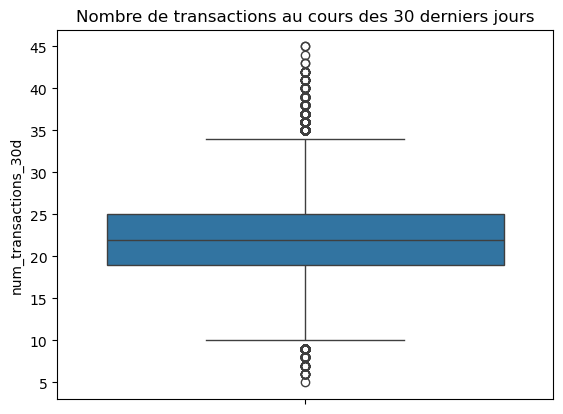

In [72]:
sns.boxplot(y=df['num_transactions_30d'])
plt.title('Nombre de transactions au cours des 30 derniers jours')
plt.show()

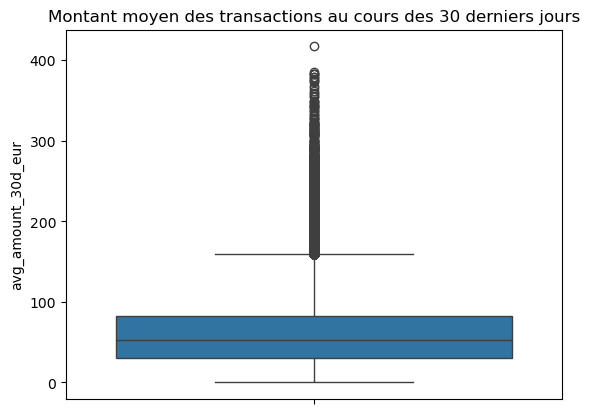

In [73]:
sns.boxplot(y=df['avg_amount_30d_eur'])
plt.title('Montant moyen des transactions au cours des 30 derniers jours')
plt.show()

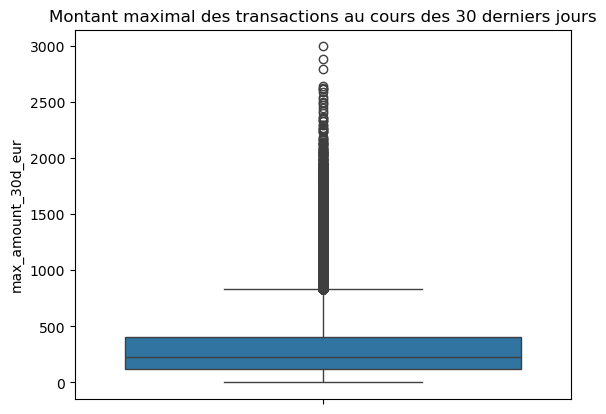

In [74]:
sns.boxplot(y=df['max_amount_30d_eur'])
plt.title('Montant maximal des transactions au cours des 30 derniers jours')
plt.show()

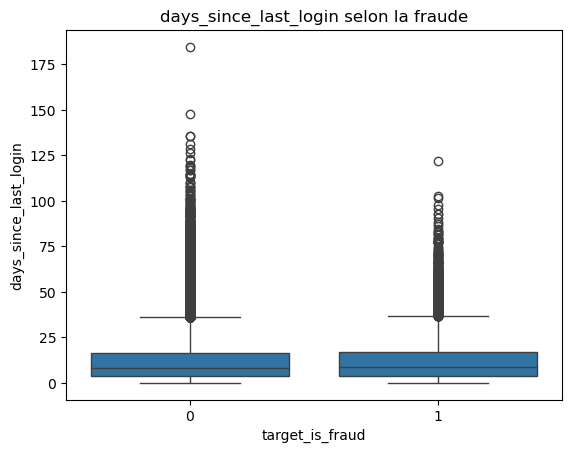

In [75]:
sns.boxplot(x=df['target_is_fraud'], y=df['days_since_last_login'])
plt.title('days_since_last_login selon la fraude')
plt.show()

In [76]:
df.groupby('target_is_fraud')['support_tickets_90d'].value_counts(normalize=True)

target_is_fraud  support_tickets_90d
0                0                      0.450770
                 1                      0.359752
                 2                      0.142214
                 3                      0.037990
                 4                      0.007803
                 5                      0.001245
                 6                      0.000212
                 7                      0.000014
1                0                      0.445307
                 1                      0.362706
                 2                      0.143210
                 3                      0.037599
                 4                      0.009073
                 5                      0.001887
                 6                      0.000218
Name: proportion, dtype: float64

In [77]:
df.groupby('target_is_fraud')['chargebacks_12m'].value_counts(normalize=True)

target_is_fraud  chargebacks_12m
0                0                  0.956313
                 1                  0.042893
                 2                  0.000773
                 3                  0.000021
1                0                  0.898381
                 1                  0.096755
                 2                  0.004791
                 3                  0.000073
Name: proportion, dtype: float64

In [78]:
df.groupby('target_is_fraud')['failed_payments_6m'].value_counts(normalize=True)

target_is_fraud  failed_payments_6m
0                0                     0.713698
                 1                     0.241453
                 2                     0.040431
                 3                     0.004083
                 4                     0.000328
                 5                     0.000007
1                0                     0.610147
                 1                     0.302606
                 2                     0.073601
                 3                     0.012049
                 4                     0.001234
                 5                     0.000290
                 6                     0.000073
Name: proportion, dtype: float64

1 > 0

## Device & Risk Signals

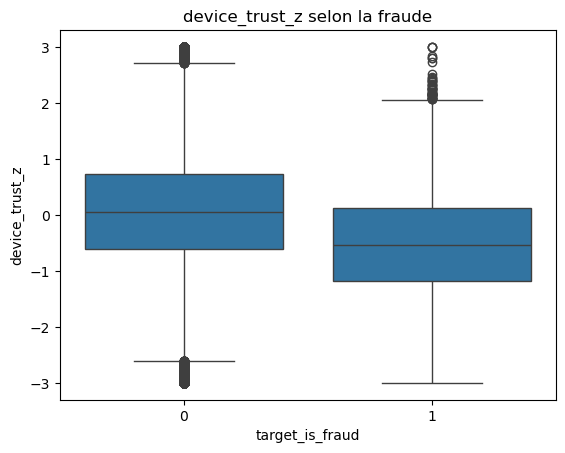

In [79]:
sns.boxplot(x=df['target_is_fraud'], y=df['device_trust_z'])
plt.title('device_trust_z selon la fraude')
plt.show()

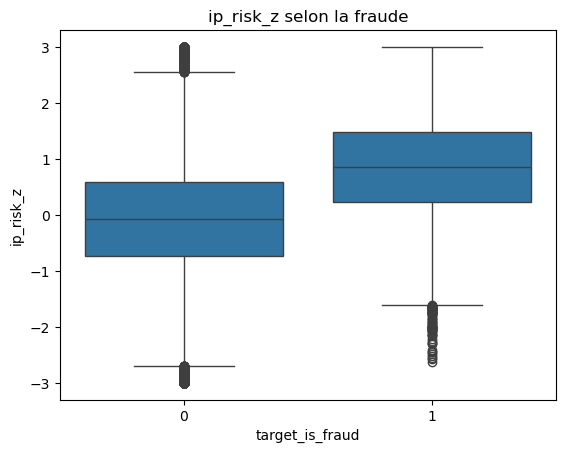

In [80]:
sns.boxplot(x=df['target_is_fraud'], y=df['ip_risk_z'])
plt.title('ip_risk_z selon la fraude')
plt.show()

In [81]:
df.groupby('target_is_fraud')['is_vpn'].value_counts(normalize=True)

target_is_fraud  is_vpn
0                0         0.931823
                 1         0.068177
1                0         0.790811
                 1         0.209189
Name: proportion, dtype: float64

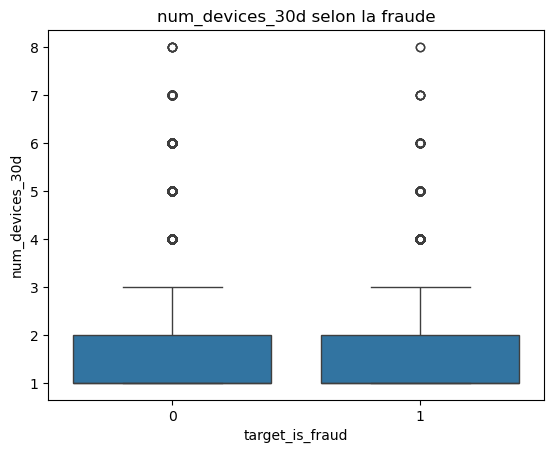

In [82]:
sns.boxplot(x=df['target_is_fraud'], y=df['num_devices_30d'])
plt.title('num_devices_30d selon la fraude')
plt.show()

In [83]:
df.groupby('target_is_fraud')['is_new_device'].value_counts(normalize=True)

target_is_fraud  is_new_device
0                0                0.835648
                 1                0.164352
1                0                0.640488
                 1                0.359512
Name: proportion, dtype: float64

## Geographic Information

In [87]:
df.groupby('target_is_fraud')['country'].value_counts(normalize=True)

target_is_fraud  country
0                FR         0.716351
                 CH         0.049958
                 BE         0.048994
                 DE         0.039344
                 IT         0.030303
                 ES         0.029859
                 GB         0.029824
                 NL         0.020380
                 CA         0.010292
                 US         0.010012
                 MA         0.004972
                 TN         0.004938
                 DZ         0.004774
1                FR         0.722726
                 CH         0.050519
                 BE         0.046309
                 DE         0.040720
                 IT         0.030340
                 ES         0.028018
                 GB         0.027002
                 NL         0.020396
                 CA         0.010743
                 US         0.009001
                 MA         0.005154
                 DZ         0.004791
                 TN         0.004282
Name: proport

In [88]:
df.groupby('target_is_fraud')['region'].value_counts(normalize=True)

target_is_fraud  region                    
0                Île-de-France                 0.279750
                 Auvergne-Rhône-Alpes          0.130610
                 Provence-Alpes-Côte d'Azur    0.080718
                 Nouvelle-Aquitaine            0.079754
                 Hauts-de-France               0.070780
                 Occitanie                     0.069921
                 Grand Est                     0.068718
                 Pays de la Loire              0.060126
                 Bretagne                      0.050016
                 Centre-Val de Loire           0.040488
                 Normandie                     0.039371
                 Bourgogne-Franche-Comté       0.029748
1                Île-de-France                 0.274079
                 Auvergne-Rhône-Alpes          0.130963
                 Nouvelle-Aquitaine            0.083158
                 Provence-Alpes-Côte d'Azur    0.082053
                 Occitanie                     0.073617
    

## Miscellaneous & Operational Fields

In [112]:
signup_dt = pd.to_datetime(df['signup_date'])
df.groupby(signup_dt.dt.month)['target_is_fraud'].mean()

signup_date
1     0.083810
2     0.086860
3     0.085067
4     0.083403
5     0.090606
6     0.087071
7     0.087508
8     0.083035
9     0.084510
10    0.086496
11    0.087982
12    0.086872
Name: target_is_fraud, dtype: float64

In [113]:
df.groupby(signup_dt.dt.year)['target_is_fraud'].mean()

signup_date
2024    0.086674
2025    0.085539
Name: target_is_fraud, dtype: float64

In [114]:
cols = [f'internal_signal_{i}' for i in range(1,9)]
df[cols + ['target_is_fraud']].corr()['target_is_fraud'].sort_values(ascending=False)

target_is_fraud      1.000000
internal_signal_2    0.003761
internal_signal_6    0.002305
internal_signal_3    0.000794
internal_signal_1    0.000692
internal_signal_5    0.000483
internal_signal_8   -0.001099
internal_signal_7   -0.001294
internal_signal_4   -0.001898
Name: target_is_fraud, dtype: float64

Les variables sont très peu corrélées avec la cible (corr proche de 0). Donc elles ne semblent pas fortement liées au risque de fraude.

In [116]:
df['terms_accepted_flag'].value_counts()

terms_accepted_flag
1    160000
Name: count, dtype: int64

-> A supprimer.

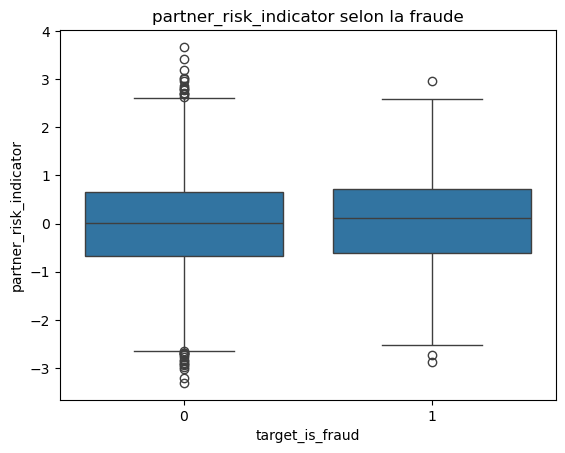

In [119]:
sns.boxplot(x='target_is_fraud', y='partner_risk_indicator', data=df)
plt.title('partner_risk_indicator selon la fraude')
plt.show()

In [121]:
df['target_is_fraud'].value_counts(normalize=True)

target_is_fraud
0    0.913894
1    0.086106
Name: proportion, dtype: float64